# First look at data from the ALS 6.3.1 Photon Energy sensor
awojdyla@lbl.gov, johnnyho@lbl.gov

As part of the Monoplus project, we are commissionning an novel Photon Energy sensor.
Here is a first look at the data, with the intent to denoise.

Camera is Emergent LZ-16KG5-M-E2
https://emergentvisiontec.com/products/pinnacle-lz-100gige-cameras-rdma-line-scan/pinnacle-lz-16kg5/

In [1]:
import numpy as np
filepath = "../data/20260306_ALS631_PES.txt"
data = np.loadtxt(filepath)

px_m = 5e-6
x_m = np.arange(data.shape[1]) * px_m
data0 = data[0, :]
mask0 = data0<20000

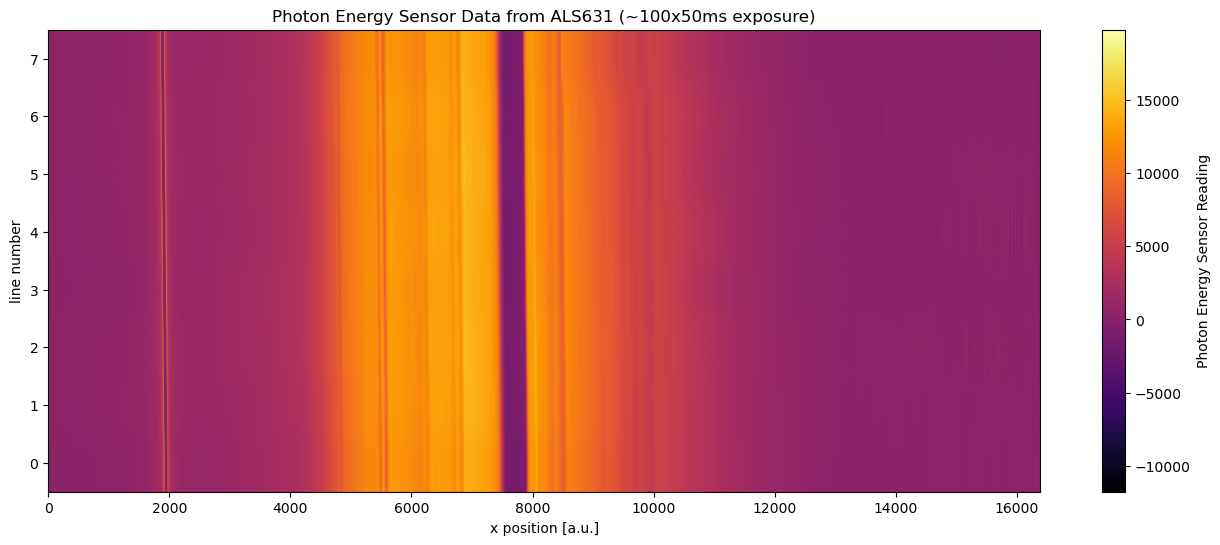

In [2]:
import matplotlib.pyplot as plt
mask = data<20000
plt.figure(figsize=(16, 6))
plt.imshow(data*mask, aspect='auto', origin='lower',cmap='inferno')
plt.colorbar(label='Photon Energy Sensor Reading')
plt.title('Photon Energy Sensor Data from ALS631 (~100x50ms exposure)')
plt.xlabel('x position [a.u.]')
plt.ylabel('line number')
plt.show()

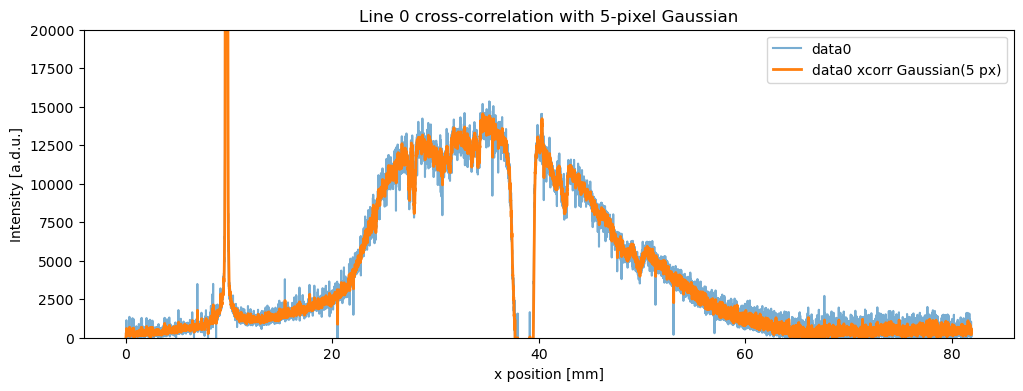

In [3]:
data0 = data[0,:]
# Cross-correlate data0 with a 5-pixel Gaussian kernel
x = np.arange(10) - 2
sigma = 1.0
gauss5 = np.exp(-0.5 * (x / sigma) ** 2)
gauss5 /= gauss5.sum()

data0_xcorr_gauss = np.correlate(data0, gauss5, mode='same')

plt.figure(figsize=(12, 4))
plt.plot(x_m*1e3,data0, label='data0', alpha=0.6)
plt.plot(x_m*1e3,data0_xcorr_gauss, label='data0 xcorr Gaussian(5 px)', linewidth=2)
plt.xlabel('x position [mm]')
plt.ylabel('Intensity [a.d.u.]')
plt.title('Line 0 cross-correlation with 5-pixel Gaussian')
#plt.xlim(0, len(data0))
plt.legend()
plt.ylim(0, 20000)
plt.show()

## coarse energy scaling
The slit at 25 um provide a resolution of about 5000RP at 500eV

In [4]:
slit_size_m = 25e-6
RP = 5000
E0_eV = 500

DE_eV = E0_eV/ RP*px_m/ slit_size_m
print(f"Estimated energy resolution per pixel: {DE_eV*1e3:.2f} meV")
Es_eV = E0_eV + np.arange(len(x_m)) * DE_eV

Estimated energy resolution per pixel: 20.00 meV


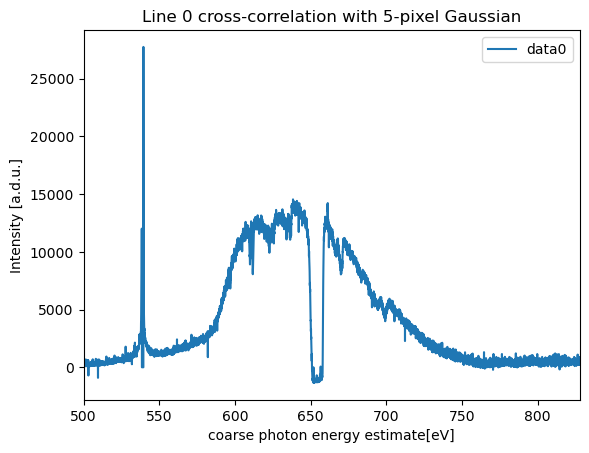

In [5]:
plt.plot(Es_eV, data0_xcorr_gauss*mask0, label='data0')
plt.xlabel('coarse photon energy estimate[eV]')
plt.ylabel('Intensity [a.d.u.]')
plt.xlim(Es_eV[0], Es_eV[-1])
plt.title('Line 0 cross-correlation with 5-pixel Gaussian')
plt.legend()
plt.show()

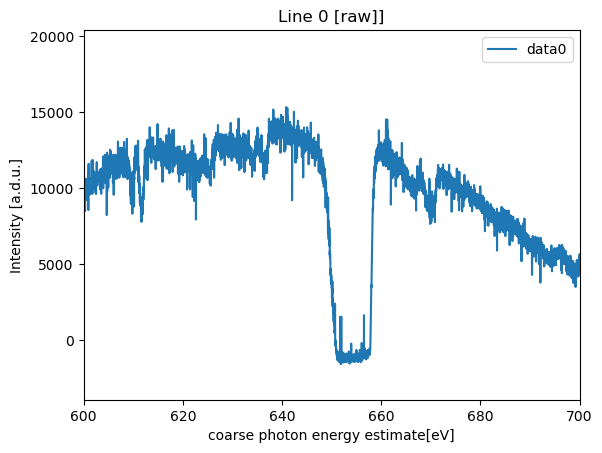

In [6]:
plt.plot(Es_eV, data0*mask0, label='data0')
plt.xlabel('coarse photon energy estimate[eV]')
plt.ylabel('Intensity [a.d.u.]')
plt.xlim((600, 700))
plt.title('Line 0 [raw]]')
plt.legend()
plt.show()